In [1]:
from IPython.display import Markdown, display
# Initialization, styling configuration, and helper utilities
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import torch
from ipywidgets import interact

# Load course helper utilities (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/ML-DL/01_foundations/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp

import importlib
importlib.reload(hp)

hp.setup_theme()

# Quantifying Uncertainty: Information Theory

- Information theory was founded by **Claude Shannon (1948)** to determine the fundamental physical limits of signal processing, data compression, and transmission over noisy communication channels.
- In machine learning and deep learning, information theory provides the theoretical foundation for:
  - Quantifying uncertainty in probability distributions
  - Measuring the degree of surprise or information content of events
  - Formulating principled loss functions (e.g., cross-entropy loss, Kullback–Leibler divergence)
  - Characterizing statistical dependencies and representation learning (e.g., mutual information)

<small>📖 *Source: [Shannon, C. E. (1948). A Mathematical Theory of Communication. Bell System Technical Journal, 27(3), 379–423](https://doi.org/10.1002/j.1538-7305.1948.tb01338.x)*</small><br>
<small>📖 *Source: MacKay, D. J. C. (2003). Information Theory, Inference, and Learning Algorithms. Cambridge University Press. ISBN: 978-0-521-64298-9*</small>


## Motivating Example: Two Coins

- Assume we have two coins:
  - A **biased coin** $c_1$ with $p(c_1 = \mathrm{H}) = 0.75$ and $p(c_1 = \mathrm{T}) = 0.25$
  - A **fair coin** $c_2$ with $p(c_2 = \mathrm{H}) = 0.50$ and $p(c_2 = \mathrm{T}) = 0.50$
- Both coins are tossed independently out of sight. You are asked to guess the outcome, but you have a "joker": you may ask for the outcome of **one** coin.
- **Pedagogical Question:** The outcome of *which* coin provides you with more informative content?


- Because the coin tosses are statistically independent, the joint probability distribution is given by the product rule $p(c_1, c_2) = p(c_1)p(c_2)$:
  - $p(c_1 = \mathrm{H}, c_2 = \mathrm{H}) = 0.75 \times 0.50 = 0.375$
  - $p(c_1 = \mathrm{H}, c_2 = \mathrm{T}) = 0.75 \times 0.50 = 0.375$
  - $p(c_1 = \mathrm{T}, c_2 = \mathrm{H}) = 0.25 \times 0.50 = 0.125$
  - $p(c_1 = \mathrm{T}, c_2 = \mathrm{T}) = 0.25 \times 0.50 = 0.125$


### Two Coins: Conditional Uncertainty & Resolution

- Consider the conditional probability of fair coin $c_2$ given the outcome of biased coin $c_1$:
  $$p(c_2 = \mathrm{H} \mid c_1 = \mathrm{H}) = \frac{p(c_1 = \mathrm{H}, c_2 = \mathrm{H})}{p(c_1 = \mathrm{H})} = \frac{0.375}{0.75} = 0.50$$
  $$p(c_2 = \mathrm{H} \mid c_1 = \mathrm{T}) = \frac{p(c_1 = \mathrm{T}, c_2 = \mathrm{H})}{p(c_1 = \mathrm{T})} = \frac{0.125}{0.25} = 0.50$$
- Learning the outcome of the biased coin leaves our uncertainty about the fair coin completely unchanged ($0.50$).


### Two Coins: Resolving Uncertainty

- Now consider the converse — observing the outcome of the fair coin $c_2$:
  $$p(c_1 = \mathrm{H} \mid c_2 = \mathrm{H}) = \frac{0.375}{0.50} = 0.75$$
  $$p(c_1 = \mathrm{T} \mid c_2 = \mathrm{H}) = \frac{0.125}{0.50} = 0.25$$
- Prior uncertainty about $c_1$ was already low ($75\%$ heads), but uncertainty about $c_2$ was maximal ($50/50$).
- Learning the outcome of the fair coin resolves a greater amount of prior uncertainty!

> 💡 **Key Takeaway:** An outcome conveys more information when it resolves greater prior uncertainty. Unlikely or unpredictable events carry higher information content than predictable ones.


## Degree of Surprise and Information Content

- How do we mathematically quantify the information gained upon observing an event $x$?
- The information content can be viewed as the **degree of surprise**:
  - A highly improbable event conveys substantial information.
  - A likely event conveys very little information.
  - A certain event ($p(x) = 1$) conveys zero information: $h(x) = 0$.
- **Axiom of Additivity:** If two events $x$ and $y$ are statistically independent ($p(x, y) = p(x)p(y)$), the information gained from observing both must equal the sum of the individual informations:
  $$h(x, y) = h(x) + h(y)$$
- The unique continuous monotonic function satisfying this relation is the negative logarithm:
  $$h(x) = -\log_2 p(x) \quad \text{(bits)} \quad \text{or} \quad h(x) = -\ln p(x) \quad \text{(nats)}$$
  where $1 \text{ nat} = \frac{1}{\ln 2} \approx 1.443 \text{ bits}$.


## Shannon Entropy

- To quantify the expected uncertainty in an entire probability distribution $p(x)$, we evaluate the expectation of the self-information $h(x)$:
  $$H[x] = \mathbb{E}[h(x)] = -\sum_x p(x) \log_2 p(x) \quad \text{(bits)}$$
  or in natural units (nats):
  $$H[x] = -\sum_x p(x) \ln p(x) \quad \text{(nats)}$$

- **Properties of Shannon Entropy:**
  - **Non-negativity:** $H[x] \ge 0$, because $0 \le p(x) \le 1 \implies -\ln p(x) \ge 0$.
  - **Minimum value:** $H[x] = 0$ if and only if the system is completely deterministic (one $p(x_i) = 1$ and all other $p(x_j) = 0$).
  - **Continuity at zero:** Because $\lim_{\epsilon \to 0} \epsilon \ln \epsilon = 0$, we define $p(x)\ln p(x) = 0$ whenever $p(x) = 0$.
  - Broad, spread-out distributions have **high** entropy; sharply peaked distributions have **low** entropy.


### Interactive Exploration: Entropy of a Bernoulli Distribution

- For a binary random variable with success parameter $p \in [0, 1]$:
  $$H(p) = -p \ln p - (1 - p) \ln(1 - p)$$
- The entropy is symmetric around $p = 0.5$ and achieves its global maximum at $H(0.5) = \ln 2 \approx 0.693$ nats ($1$ bit).


In [2]:
def binary_entropy(p: float) -> float:
    """Computes the Shannon entropy of a Bernoulli distribution with parameter p in nats."""
    if p <= 0.0 or p >= 1.0:
        return 0.0
    return -((1.0 - p) * np.log(1.0 - p) + p * np.log(p))

# Grid of probability values p in [0, 1]
sp = np.linspace(0.0, 1.0, 101)

# Evaluating entropy at characteristic probabilities to demonstrate inputs and outputs
sample_probabilities = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
print("--- Bernoulli Entropy: Inputs and Outputs ---")
for prob in sample_probabilities:
    h_nats = binary_entropy(prob)
    h_bits = h_nats / np.log(2.0)
    print(f"Input p = {prob:.2f} -> Output H[p] = {h_nats:.4f} nats ({h_bits:.4f} bits)")


--- Bernoulli Entropy: Inputs and Outputs ---
Input p = 0.00 -> Output H[p] = 0.0000 nats (0.0000 bits)
Input p = 0.10 -> Output H[p] = 0.3251 nats (0.4690 bits)
Input p = 0.25 -> Output H[p] = 0.5623 nats (0.8113 bits)
Input p = 0.50 -> Output H[p] = 0.6931 nats (1.0000 bits)
Input p = 0.75 -> Output H[p] = 0.5623 nats (0.8113 bits)
Input p = 0.90 -> Output H[p] = 0.3251 nats (0.4690 bits)
Input p = 1.00 -> Output H[p] = 0.0000 nats (0.0000 bits)


In [3]:
def plot_bernoulli_entropy(p: float = 0.5):
    """Visualizes the entropy curve of a Bernoulli distribution and highlights parameter p."""
    h_nats = binary_entropy(p)
    h_bits = h_nats / np.log(2.0)
    print(f"Selected: p = {p:.2f} -> H[p] = {h_nats:.3f} nats ({h_bits:.3f} bits)")

    plt.figure(figsize=(8, 4.2))
    plt.plot(sp, [binary_entropy(val) for val in sp], color='red', lw=2.5, label='Entropy $H[p]$ (nats)')
    plt.scatter([p], [h_nats], color='blue', s=70, zorder=5, label=f'Current: $p={p:.2f}$')
    plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
    plt.title('Entropy of a Bernoulli Distribution', fontsize=15)
    plt.xlabel('Probability $p$', fontsize=13)
    plt.ylabel('Entropy (nats)', fontsize=13)
    plt.legend(loc='lower center', fontsize=11)
    plt.tight_layout()
    plt.show()


In [4]:
interact(plot_bernoulli_entropy, p=(0.0, 1.0, 0.05));


interactive(children=(FloatSlider(value=0.5, description='p', max=1.0, step=0.05), Output()), _dom_classes=('w…

## Data Compression: Variable-Length Coding

- Suppose a sender transmits the state of an 8-state discrete variable $x \in \{a, b, c, d, e, f, g, h\}$ to a receiver.
- **Case 1: Uniform Distribution** ($p_i = 1/8$ for all $i$):
  $$H[x] = -8 \times \left( \frac{1}{8}\log_2 \frac{1}{8} \right) = 3 \text{ bits}$$
  Transmitting each state requires a 3-bit binary code (e.g., $000, 001, \dots, 111$).
- **Case 2: Non-uniform Distribution (Cover & Thomas, 1991):**
  - Probabilities: $(p_a, p_b, p_c, p_d, p_e, p_f, p_g, p_h) = \left( \frac{1}{2}, \frac{1}{4}, \frac{1}{8}, \frac{1}{16}, \frac{1}{64}, \frac{1}{64}, \frac{1}{64}, \frac{1}{64} \right)$
  - Entropy: $H[x] = 2 \text{ bits}$.
  - Optimal prefix codes assign shorter strings to frequent states:
    $a \to \texttt{0}$, $b \to \texttt{10}$, $c \to \texttt{110}$, $d \to \texttt{1110}$, and $e, f, g, h \to \texttt{111100} \dots \texttt{111111}$.


### Shannon's Noiseless Coding Theorem

- The average transmitted code length for the Cover–Thomas 8-state variable is:
  $$\mathbb{E}[\text{length}] = \frac{1}{2}(1) + \frac{1}{4}(2) + \frac{1}{8}(3) + \frac{1}{16}(4) + 4 \times \frac{1}{64}(6) = 2 \text{ bits} = H[x]$$

> 💡 **Shannon's Noiseless Coding Theorem (1948):** The entropy $H[x]$ is the fundamental physical lower bound on the expected number of bits required to encode and transmit the state of a random variable.

<small>📖 *Source: [Cover, T.M., Thomas, J.A. (2005). Elements of Information Theory. ](https://doi.org/10.1002/047174882X)*</small><br>
<small>📖 *Source: [Shannon, C. E. (1948). A Mathematical Theory of Communication. Bell System Technical Journal, 27(3), 379–423](https://doi.org/10.1002/j.1538-7305.1948.tb01338.x)*</small>


## Physics Perspective: Microstates and Macrostates

- In statistical mechanics, consider allocating $N$ identical particles into discrete bins such that the $i^\mathrm{th}$ bin contains $n_i$ particles ($\sum_i n_i = N$).
- The total number of distinct arrangements of particles among the bins without distinguishing order within a bin is the **multiplicity**:
  $$W = \frac{N!}{\prod_i n_i!} \implies H = \frac{1}{N} \ln W$$
- Applying **Stirling's approximation** $\ln N! \simeq N \ln N - N$ in the macroscopic limit $N \to \infty$:
  $$H = -\lim_{N \to \infty} \sum_i \frac{n_i}{N} \ln \frac{n_i}{N} = -\sum_i p_i \ln p_i$$
- **Microstate:** The exact configuration of individual particles in specific bins.
- **Macrostate:** The aggregate occupation frequencies $\{p_i\}$. Entropy measures the log-multiplicity of microstates that give rise to the same macrostate.


### Maximum Entropy for Discrete Variables

- Which discrete distribution over $M$ states maximizes entropy? Using a Lagrange multiplier $\lambda$ with normalization $\sum_{i=1}^M p(x_i) = 1$:
  $$\widetilde{H} = -\sum_{i=1}^M p(x_i) \ln p(x_i) + \lambda \left( \sum_{i=1}^M p(x_i) - 1 \right)$$
- Differentiating with respect to $p(x_i)$ and setting the derivative to zero yields the **uniform distribution**:
  $$\frac{\partial \widetilde{H}}{\partial p(x_i)} = -\ln p(x_i) - 1 + \lambda = 0 \implies p(x_i) = \frac{1}{M}$$
- The maximum discrete entropy over $M$ states is $H_\mathrm{max} = \ln M$.
- Evaluating the second derivative confirms a strict maximum:
  $$\frac{\partial^2 \widetilde{H}}{\partial p(x_i) \partial p(x_j)} = -I_{ij} \frac{1}{p_i} < 0$$


## Differential Entropy for Continuous Variables

- To extend entropy to continuous distributions $p(x)$, divide the real line into intervals of width $\Delta$.
- By the mean value theorem, $\int_{i\Delta}^{(i+1)\Delta} p(x) \, \mathrm{d}x = p(x_i)\Delta$.
- Quantizing $x$ to discrete $x_i$ gives the discrete entropy:
  $$H_\Delta = -\sum_i p(x_i)\Delta \ln \left( p(x_i)\Delta \right) = -\sum_i p(x_i)\Delta \ln p(x_i) - \ln \Delta$$
- Omitting the diverging term $-\ln\Delta$ and taking the continuum limit $\Delta \to 0$ defines the **differential entropy**:
  $$H[x] = -\int p(x) \ln p(x) \, \mathrm{d}x$$
- For continuous multivariate densities over $\mathbf{x} \in \mathbb{R}^D$:
  $$H[\mathbf{x}] = -\int p(\mathbf{x}) \ln p(\mathbf{x}) \, \mathrm{d}\mathbf{x}$$


### Continuous vs. Discrete Entropy: Divergence

- The discrete and continuous forms differ by $-\ln\Delta$, which diverges as $\Delta \to 0$:
  $$\lim_{\Delta \to 0} (-\ln\Delta) = +\infty$$

> ⚠️ **Physical Interpretation:** Specifying a continuous real variable with infinite precision requires an **infinite number of bits**!
>
> Unlike discrete entropy (which measures absolute uncertainty), differential entropy measures uncertainty relative to coordinate resolution.


### Maximum Differential Entropy: The Gaussian

- To prevent entropy from growing arbitrarily by spreading mass infinitely, we constrain the first two moments (mean $\mu$ and variance $\sigma^2$):
  $$\int_{-\infty}^\infty p(x) \, \mathrm{d}x = 1, \quad \int_{-\infty}^\infty x p(x) \, \mathrm{d}x = \mu, \quad \int_{-\infty}^\infty (x - \mu)^2 p(x) \, \mathrm{d}x = \sigma^2$$
- Maximizing $H[x]$ subject to these constraints using Lagrange multipliers and the calculus of variations yields the **Gaussian distribution**:
  $$p(x) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$$
- The differential entropy of the univariate Gaussian is:
  $$H[x] = \frac{1}{2} \left[ 1 + \ln(2\pi\sigma^2) \right]$$

> ⚠️ **Crucial Distinction:** Unlike discrete entropy, differential entropy can be **negative**! Specifically, $H[x] < 0$ whenever $\sigma^2 < \frac{1}{2\pi e} \approx 0.0585$.


In [5]:
def gaussian_differential_entropy(sigma2: float) -> float:
    """Computes the differential entropy of a univariate Gaussian with variance sigma2 in nats."""
    return 0.5 * (1.0 + np.log(2.0 * np.pi * sigma2))

# Characteristic variances demonstrating negative, zero, and positive differential entropy
zero_crossing_sigma2 = 1.0 / (2.0 * np.pi * np.e)
sample_variances = [0.01, 0.03, zero_crossing_sigma2, 0.20, 1.00]

display(Markdown(r"**Gaussian Differential Entropy $\mathrm{H}[x] = \frac{1}{2} \{ 1 + \ln(2\pi\sigma^2) \}$:**"))
for s2 in sample_variances:
    h = gaussian_differential_entropy(s2)
    regime = "Negative ($\mathrm{H} < 0$)" if h < -1e-5 else ("Zero crossing ($\mathrm{H} = 0$)" if abs(h) <= 1e-5 else "Positive ($\mathrm{H} > 0$)")
    display(Markdown(rf"Input variance $\sigma^2 = {s2:.4f} \implies$ Output $\mathrm{{H}}[x] = {h:.4f}$ nats [{regime}]"))


--- Gaussian Differential Entropy: Inputs and Outputs ---
Input sigma^2 = 0.0100 -> Output H[x] = -0.8836 nats [Negative (H < 0)]
Input sigma^2 = 0.0300 -> Output H[x] = -0.3343 nats [Negative (H < 0)]
Input sigma^2 = 0.0585 -> Output H[x] = 0.0000 nats [Zero crossing]
Input sigma^2 = 0.2000 -> Output H[x] = 0.6142 nats [Positive (H > 0)]
Input sigma^2 = 1.0000 -> Output H[x] = 1.4189 nats [Positive (H > 0)]


In [6]:
def plot_gaussian_differential_entropy():
    """Visualizes Gaussian differential entropy across variance values, highlighting the negative regime."""
    sigma2_vals = np.linspace(0.01, 1.0, 200)
    entropy_vals = [gaussian_differential_entropy(s2) for s2 in sigma2_vals]
    zero_cross = 1.0 / (2.0 * np.pi * np.e)

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.plot(sigma2_vals, entropy_vals, color='#1f77b4', lw=2.5, label=r'$H[x] = \frac{1}{2}[1 + \ln(2\pi\sigma^2)]$')
    ax.axhline(0, color='black', linestyle=':', alpha=0.7)
    ax.axvline(zero_cross, color='#d62728', linestyle='--', alpha=0.8,
               label=r'Zero-crossing $\sigma^2 = \frac{1}{2\pi e} \approx 0.0585$')
    ax.scatter([zero_cross], [0], color='#d62728', s=70, zorder=5)

    ax.set_title(r'Differential Entropy of a Gaussian vs Variance $\sigma^2$', fontsize=14)
    ax.set_xlabel(r'Variance $\sigma^2$', fontsize=12)
    ax.set_ylabel('Differential Entropy $H[x]$ (nats)', fontsize=12)
    ax.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()


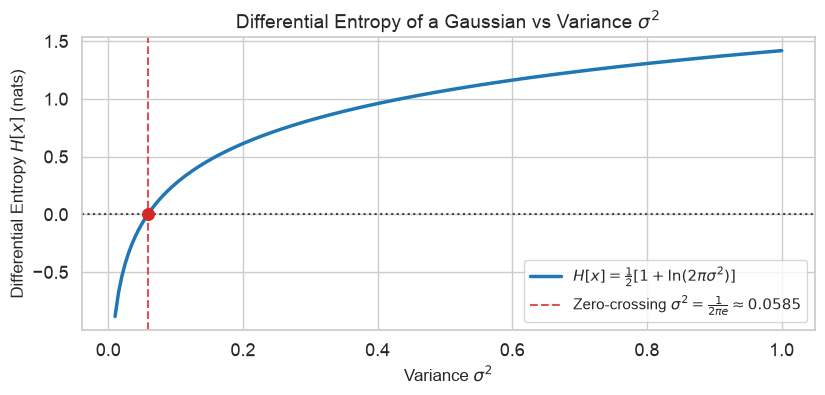

In [7]:
plot_gaussian_differential_entropy();


# Comparing Distributions: Kullback–Leibler Divergence

- If we encode data from true $p(\mathbf{x})$ using an approximating model $q(\mathbf{x})$, the average **additional** amount of information (in nats) required to specify $\mathbf{x}$ is:
  $$\mathrm{KL}(p \parallel q) = -\int p(\mathbf{x}) \ln \frac{q(\mathbf{x})}{p(\mathbf{x})} \, \mathrm{d}\mathbf{x} = \int p(\mathbf{x}) \ln \frac{p(\mathbf{x})}{q(\mathbf{x})} \, \mathrm{d}\mathbf{x}$$
- This fundamental quantity is known as the **relative entropy** or **Kullback–Leibler (KL) divergence** (Kullback & Leibler, 1951).
- For discrete distributions:
  $$\mathrm{KL}(p \parallel q) = \sum_x p(x) \ln \frac{p(x)}{q(x)} = -\sum_x p(x) \ln \frac{q(x)}{p(x)}$$

> ⚠️ **Asymmetry:** The KL divergence is **not** a symmetric distance metric: $\mathrm{KL}(p \parallel q) \neq \mathrm{KL}(q \parallel p)$. In machine learning, minimizing $\mathrm{KL}(p \parallel q)$ vs $\mathrm{KL}(q \parallel p)$ yields fundamentally different behaviors (mode covering vs mode seeking).

<small>📖 *Source: [Kullback, S., Leibler, R.A. (1951). On Information and Sufficiency. The Annals of Mathematical Statistics, 22(1), 79-86](https://doi.org/10.1214/aoms/1177729694)*</small>


### Convexity and Jensen's Inequality

- A function $f(x)$ is **convex** if every chord lies on or above the curve ($f''(x) \ge 0$):
  $$f(\lambda a + (1 - \lambda)b) \le \lambda f(a) + (1 - \lambda)f(b), \quad \text{for any } 0 \le \lambda \le 1$$
- **Jensen's Inequality:** For any convex function $f$ and random variable $x$, $f(\mathbb{E}[x]) \le \mathbb{E}[f(x)]$.
- **Proof that $\mathrm{KL}(p \parallel q) \ge 0$:**
  - Because $f(t) = -\ln t$ is strictly convex ($f''(t) = 1/t^2 > 0$ for all $t > 0$):
    $$\mathrm{KL}(p \parallel q) = -\int p(\mathbf{x}) \ln \left( \frac{q(\mathbf{x})}{p(\mathbf{x})} \right) \mathrm{d}\mathbf{x} \ge -\ln \left( \int q(\mathbf{x}) \, \mathrm{d}\mathbf{x} \right) = -\ln(1) = 0$$
  - Because $-\ln t$ is strictly convex, equality holds if and only if $q(\mathbf{x}) = p(\mathbf{x})$ almost everywhere!


### Connection to Machine Learning: KL Divergence & Maximum Likelihood

- Suppose data is drawn from unknown $p(\mathbf{x})$, and we parameterize a model $q(\mathbf{x} \mid \boldsymbol{\theta})$:
  $$\mathrm{KL}(p \parallel q_{\boldsymbol{\theta}}) = -\int p(\mathbf{x}) \ln q(\mathbf{x} \mid \boldsymbol{\theta}) \, \mathrm{d}\mathbf{x} + \int p(\mathbf{x}) \ln p(\mathbf{x}) \, \mathrm{d}\mathbf{x}$$
- Given finite training observations $\mathcal{D} = \{\mathbf{x}_n\}_{n=1}^N \sim p(\mathbf{x})$, we approximate the expectation empirically:
  $$\mathrm{KL}(p \parallel q_{\boldsymbol{\theta}}) \simeq -\frac{1}{N}\sum_{n=1}^N \ln q(\mathbf{x}_n \mid \boldsymbol{\theta}) + \mathrm{const}$$

> 💡 **Fundamental ML Equivalence:** Minimizing the empirical KL divergence to a parametric model is mathematically identical to **maximizing the log-likelihood** (or minimizing cross-entropy loss).


### Discrete KL Divergence: Numerical Computation

- For two discrete probability vectors $\mathbf{p}, \mathbf{q} \in \mathbb{R}^K$:
  $$\mathrm{KL}(\mathbf{p} \parallel \mathbf{q}) = \sum_{k=1}^K p_k \ln \frac{p_k}{q_k} = \sum_{k=1}^K p_k s_k$$
  where the elementwise surprise-ratio score $s_k$ is defined by:
  $$s_k = \begin{cases} \ln(p_k / q_k), & p_k > 0 \text{ and } q_k > 0 \\ 0, & p_k = 0 \text{ and } q_k \ge 0 \\ +\infty, & p_k > 0 \text{ and } q_k = 0 \end{cases}$$
- If the model assigns $q_k = 0$ to an event that actually occurs ($p_k > 0$), the penalty is infinite ($\mathrm{KL} = +\infty$).


In [8]:
def kld_entr(p: torch.Tensor, q: torch.Tensor) -> float:
    """Computes elementwise score for KL divergence."""
    if p > 0 and q > 0:
        return torch.log(p / q).item()
    elif p == 0 and q >= 0:
        return 0.0
    else:
        return float('inf')

def kld(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    """Computes discrete KL divergence KL(p || q) in nats."""
    if not (torch.isclose(torch.sum(p), torch.tensor(1.0)) and torch.all(p >= 0)):
        raise ValueError("p must be a valid probability distribution")
    if not (torch.isclose(torch.sum(q), torch.tensor(1.0)) and torch.all(q >= 0)):
        raise ValueError("q must be a valid probability distribution")
    if p.size() != q.size():
        raise ValueError("p and q must have the same dimension")

    scores = torch.tensor([kld_entr(pi, qi) for pi, qi in zip(p, q)], dtype=torch.float)
    return torch.sum(p * scores)


In [9]:
# Multi-class classification example with four classes
# p is one-hot target: class index 1 is active
p = torch.tensor([0.0, 1.0, 0.0, 0.0], dtype=torch.float)
q1 = torch.tensor([0.1, 0.7, 0.1, 0.1], dtype=torch.float)
q2 = torch.tensor([0.7, 0.1, 0.1, 0.1], dtype=torch.float)

display(Markdown(rf"KL divergence $\mathrm{{KL}}(p \parallel q_1) = {kld(p, q1):.4f}$ nats"))
display(Markdown(rf"KL divergence $\mathrm{{KL}}(q_1 \parallel p) = {kld(q1, p):.4f}$ nats"))
display(Markdown(rf"KL divergence $\mathrm{{KL}}(p \parallel q_2) = {kld(p, q2):.4f}$ nats"))


KL divergence KL(p || q1):  tensor(0.3567)
KL divergence KL(q1 || p):  tensor(inf)
KL divergence KL(p || q2):  tensor(2.3026)


## Cross-Entropy and Loss Functions

- The **cross-entropy** between distribution $p$ and distribution $q$ is defined as:
  $$H(p, q) = H[p] + \mathrm{KL}(p \parallel q) = -\sum_x p(x) \ln q(x) = -\mathbb{E}_{x \sim p}[\ln q(x)]$$

- **Derivation:**
  $$
  \begin{aligned}
  H(p, q) &= -\sum_x p(x) \ln p(x) + \sum_x p(x) \left( \ln p(x) - \ln q(x) \right) \\
  &= \sum_x p(x) \left( -\ln p(x) + \ln p(x) - \ln q(x) \right) \\
  &= -\sum_x p(x) \ln q(x)
  \end{aligned}
  $$

- For fixed training targets $p$, $H[p]$ is constant with respect to parameters $\boldsymbol{\theta}$:
  $$\arg\min_{\boldsymbol{\theta}} H(p, q_{\boldsymbol{\theta}}) \equiv \arg\min_{\boldsymbol{\theta}} \mathrm{KL}(p \parallel q_{\boldsymbol{\theta}})$$
- This is the foundation of `torch.nn.CrossEntropyLoss`.


In [10]:
def ce_entr(p: torch.Tensor, q: torch.Tensor) -> float:
    """Computes elementwise log term for cross-entropy."""
    if p > 0 and q > 0:
        return torch.log(q).item()
    elif p == 0 and q >= 0:
        return 0.0
    else:
        return float('-inf')

def ce(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    """Computes discrete cross-entropy H(p, q) in nats."""
    if not (torch.isclose(torch.sum(p), torch.tensor(1.0)) and torch.all(p >= 0)):
        raise ValueError("p must be a valid probability distribution")
    if not (torch.isclose(torch.sum(q), torch.tensor(1.0)) and torch.all(q >= 0)):
        raise ValueError("q must be a valid probability distribution")
    if p.size() != q.size():
        raise ValueError("p and q must have the same dimension")

    res = torch.tensor([ce_entr(pi, qi) for pi, qi in zip(p, q)], dtype=torch.float)
    return -torch.sum(p * res)

print("Cross-entropy H(p, q1): ", ce(p, q1))
print("Cross-entropy H(q1, p): ", ce(q1, p))
print("Cross-entropy H(p, q2): ", ce(p, q2))


Cross-entropy H(p, q1):  tensor(0.3567)
Cross-entropy H(q1, p):  tensor(inf)
Cross-entropy H(p, q2):  tensor(2.3026)


## Jensen–Shannon Divergence (JSD)

- Symmetric, bounded alternative to KL divergence:
  $$\mathrm{JSD}(p \parallel q) = \frac{1}{2}\mathrm{KL}(p \parallel m) + \frac{1}{2}\mathrm{KL}(q \parallel m), \quad m(x) = \frac{p(x) + q(x)}{2}$$

- **Key Properties:**
  - **Symmetry:** $\mathrm{JSD}(p \parallel q) = \mathrm{JSD}(q \parallel p)$.
  - **Boundedness:** $0 \le \mathrm{JSD}(p \parallel q) \le \ln 2$ (or $\le 1$ using $\log_2$).
  - **Always finite:** Because $m(x) > 0$ whenever $p(x) > 0$ or $q(x) > 0$.
  - $\sqrt{\mathrm{JSD}}$ is a true metric satisfying the triangle inequality (the *Jensen–Shannon distance*).
  - Formulates the foundational objective function of **Generative Adversarial Networks (GANs)** (Goodfellow et al., 2014).

<small>📖 *Source: [Goodfellow, I., et al. (2020). Generative adversarial networks. Communications of the ACM, 63(11), 139-144](https://doi.org/10.1145/3422622)*</small>


In [11]:
def jsd(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    """Computes Jensen-Shannon Divergence JSD(p || q) in nats."""
    m = 0.5 * (p + q)
    return 0.5 * kld(p, m) + 0.5 * kld(q, m)

display(Markdown(rf"$\mathrm{{JSD}}(p \parallel q_1) = {jsd(p, q1):.4f}$ nats"))
display(Markdown(rf"$\mathrm{{JSD}}(q_1 \parallel p) = {jsd(q1, p):.4f}$ nats"))
display(Markdown(rf"$\mathrm{{JSD}}(p \parallel q_2) = {jsd(p, q2):.4f}$ nats"))
display(Markdown(rf"$\mathrm{{JSD}}(q_1 \parallel q_2) = {jsd(q1, q2):.4f}$ nats"))


JSD(p || q1):  tensor(0.1173)
JSD(q1 || p):  tensor(0.1173)
JSD(p || q2):  tensor(0.5256)
JSD(q1 || q2): tensor(0.2531)


## Conditional Entropy

- Consider the joint distribution $p(\mathbf{x}, \mathbf{y})$ over two continuous or discrete sets of variables $\mathbf{x}$ and $\mathbf{y}$.
- If $\mathbf{x}$ is known, the additional information needed to specify $\mathbf{y}$ is $-\ln p(\mathbf{y} \mid \mathbf{x})$.
- The average additional information required to specify $\mathbf{y}$ given $\mathbf{x}$ is the **conditional entropy**:
  $$H[\mathbf{y} \mid \mathbf{x}] = -\iint p(\mathbf{x}, \mathbf{y}) \ln p(\mathbf{y} \mid \mathbf{x}) \, \mathrm{d}\mathbf{x} \, \mathrm{d}\mathbf{y}$$

- **Chain Rule of Entropy:** Using the product rule $p(\mathbf{x}, \mathbf{y}) = p(\mathbf{y} \mid \mathbf{x})p(\mathbf{x})$:
  $$
  \begin{aligned}
  H[\mathbf{x}, \mathbf{y}] &= -\iint p(\mathbf{x}, \mathbf{y}) \ln p(\mathbf{x}, \mathbf{y}) \, \mathrm{d}\mathbf{x} \, \mathrm{d}\mathbf{y} \\
  &= -\iint p(\mathbf{x}, \mathbf{y}) \left( \ln p(\mathbf{y} \mid \mathbf{x}) + \ln p(\mathbf{x}) \right) \mathrm{d}\mathbf{x} \, \mathrm{d}\mathbf{y} \\
  &= H[\mathbf{y} \mid \mathbf{x}] + H[\mathbf{x}]
  \end{aligned}
  $$

> 💡 **Interpretation:** The total information required to describe $(\mathbf{x}, \mathbf{y})$ equals the information in $\mathbf{x}$ plus the additional information needed to specify $\mathbf{y}$ given $\mathbf{x}$.


## Mutual Information

- When two variables $\mathbf{x}$ and $\mathbf{y}$ are independent, their joint distribution factorizes: $p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x})p(\mathbf{y})$.
- If they are not independent, we assess how close they are to independence by evaluating the KL divergence between the joint distribution and the product of the marginals:
  $$I[\mathbf{x}, \mathbf{y}] \equiv \mathrm{KL}(p(\mathbf{x}, \mathbf{y}) \parallel p(\mathbf{x})p(\mathbf{y})) = -\iint p(\mathbf{x}, \mathbf{y}) \ln \left( \frac{p(\mathbf{x})p(\mathbf{y})}{p(\mathbf{x}, \mathbf{y})} \right) \mathrm{d}\mathbf{x} \, \mathrm{d}\mathbf{y}$$
- **Fundamental Relations:**
  $$I[\mathbf{x}, \mathbf{y}] = H[\mathbf{x}] - H[\mathbf{x} \mid \mathbf{y}] = H[\mathbf{y}] - H[\mathbf{y} \mid \mathbf{x}] = H[\mathbf{x}] + H[\mathbf{y}] - H[\mathbf{x}, \mathbf{y}]$$
  - **Non-negativity:** $I[\mathbf{x}, \mathbf{y}] \ge 0$, with equality if and only if $\mathbf{x}$ and $\mathbf{y}$ are independent.
  - **Symmetry:** $I[\mathbf{x}, \mathbf{y}] = I[\mathbf{y}, \mathbf{x}]$.

> 💡 **Bayesian Interpretation:** In a Bayesian setting, $p(\mathbf{x})$ represents the prior distribution and $p(\mathbf{x} \mid \mathbf{y})$ represents the posterior distribution upon observing data $\mathbf{y}$. The mutual information $I[\mathbf{x}, \mathbf{y}]$ represents the **expected reduction in uncertainty** about $\mathbf{x}$ gained by observing $\mathbf{y}$.


### Numerical Example: Bivariate Information Measures

- Given a discrete bivariate joint distribution matrix $\mathbf{P} \in \mathbb{R}^{K_x \times K_y}$ where $P_{ij} = p(x_i, y_j)$:
  - Marginal distributions are computed by the sum rule: $p(x_i) = \sum_j P_{ij}$ and $p(y_j) = \sum_i P_{ij}$.
  - Marginal entropies: $H[x] = -\sum_i p(x_i)\ln p(x_i)$ and $H[y] = -\sum_j p(y_j)\ln p(y_j)$.
  - Joint entropy: $H[x, y] = -\sum_{i,j} P_{ij} \ln P_{ij}$.
  - Conditional entropy: $H[y \mid x] = H[x, y] - H[x]$.
  - Mutual information: $I[x, y] = H[x] + H[y] - H[x, y]$.


In [12]:
def discrete_information_measures(joint_p: torch.Tensor):
    """
    Computes marginal entropies H[x], H[y], joint entropy H[x, y],
    conditional entropy H[y | x], and mutual information I[x, y] in nats
    for a 2D discrete joint probability matrix (rows = x, columns = y).
    """
    # Marginal distributions via the sum rule of probability
    px = torch.sum(joint_p, dim=1)
    py = torch.sum(joint_p, dim=0)

    def entropy_1d(p: torch.Tensor) -> torch.Tensor:
        """Shannon entropy for a 1D marginal discrete distribution."""
        mask = p > 0
        return -torch.sum(p[mask] * torch.log(p[mask]))

    h_x = entropy_1d(px)
    h_y = entropy_1d(py)

    # Joint entropy H[x, y]
    mask_joint = joint_p > 0
    h_xy = -torch.sum(joint_p[mask_joint] * torch.log(joint_p[mask_joint]))

    # Conditional entropy H[y | x] = H[x, y] - H[x]
    h_y_given_x = h_xy - h_x

    # Mutual information I[x, y] = H[x] + H[y] - H[x, y]
    mi = h_x + h_y - h_xy

    return h_x.item(), h_y.item(), h_xy.item(), h_y_given_x.item(), mi.item()


In [13]:
def display_information_measures(title: str, joint_p: torch.Tensor):
    """Computes and formats discrete information measures for a bivariate distribution."""
    hx, hy, hxy, hy_x, mi = discrete_information_measures(joint_p)
    print(f"=== {title} ===")
    print(f"H[x]     = {hx:.4f} nats")
    print(f"H[y]     = {hy:.4f} nats")
    print(f"H[x, y]  = {hxy:.4f} nats")
    print(f"H[y | x] = {hy_x:.4f} nats")
    print(f"I[x, y]  = {mi:.4f} nats")
    return hx, hy, hxy, hy_x, mi


In [14]:
# Case 1: Correlated coin flips (e.g., noisy transmission channel)
p_joint_correlated = torch.tensor([
    [0.45, 0.05],
    [0.05, 0.45]
], dtype=torch.float)

print("Input Joint Distribution Matrix P (rows = x, cols = y):")
print(p_joint_correlated)
print()
display_information_measures("Case 1: Correlated Variables", p_joint_correlated);


Input Joint Distribution Matrix P (rows = x, cols = y):
tensor([[0.4500, 0.0500],
        [0.0500, 0.4500]])

=== Case 1: Correlated Variables ===
H[x]     = 0.6931 nats
H[y]     = 0.6931 nats
H[x, y]  = 1.0182 nats
H[y | x] = 0.3251 nats
I[x, y]  = 0.3681 nats


In [15]:
# Case 2: Completely independent variables
p_joint_independent = torch.tensor([
    [0.25, 0.25],
    [0.25, 0.25]
], dtype=torch.float)

print("Input Joint Distribution Matrix P (rows = x, cols = y):")
print(p_joint_independent)
print()
hx, hy, hxy, hy_x, mi = display_information_measures("Case 2: Independent Variables", p_joint_independent)
print(f"Verification: H[x] + H[y] = {hx+hy:.4f} nats (Strictly equal to H[x, y])")
print(f"Verification: H[y]        = {hy:.4f} nats (Strictly equal to H[y | x])")


Input Joint Distribution Matrix P (rows = x, cols = y):
tensor([[0.2500, 0.2500],
        [0.2500, 0.2500]])

=== Case 2: Independent Variables ===
H[x]     = 0.6931 nats
H[y]     = 0.6931 nats
H[x, y]  = 1.3863 nats
H[y | x] = 0.6931 nats
I[x, y]  = 0.0000 nats
Verification: H[x] + H[y] = 1.3863 nats (Strictly equal to H[x, y])
Verification: H[y]        = 0.6931 nats (Strictly equal to H[y | x])
